# LeetCode #199: Binary Tree Right Side View

https://leetcode.com/problems/binary-tree-right-side-view/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **BFS (Level Order)** | $O(n)$ | $O(n)$ |
| **DFS (Right-first)** | $O(n)$ | $O(h)$ |

---

## Understanding the Methods

### BFS (Level Order) ★
Perform a standard level-order traversal using a queue. For each level, the last node processed is the rightmost node visible from the right side. Add it to the result.

### DFS (Right-first)
Traverse the tree with a modified DFS: visit right child before left. Track the current depth. If `depth == result.size()`, this is the first node seen at this depth (i.e., the rightmost), so add it. Both approaches are $O(n)$ time; DFS uses $O(h)$ stack space which is better for balanced trees.

**Key insight:** The right side view is the last node at each level — BFS naturally captures this as the final element per level, while right-first DFS captures it as the first element seen at a new depth.

**Constraints:**
* `0 <= number of nodes <= 100`
* `-100 <= Node.val <= 100`

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<int> RightSideView(TreeNode root) {
        var result = new List<int>();
        if (root == null) return result;
        
        var queue = new Queue<TreeNode>();
        queue.Enqueue(root);
        
        while (queue.Count > 0) {
            int size = queue.Count;
            for (int i = 0; i < size; i++) {
                var node = queue.Dequeue();
                if (i == size - 1) result.Add(node.val);
                if (node.left != null) queue.Enqueue(node.left);
                if (node.right != null) queue.Enqueue(node.right);
            }
        }
        
        return result;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def rightSideView(self, root):
        if not root:
            return []
        
        result = []
        queue = deque([root])
        
        while queue:
            size = len(queue)
            for i in range(size):
                node = queue.popleft()
                if i == size - 1:
                    result.append(node.val)
                if node.left:
                    queue.append(node.left)
                if node.right:
                    queue.append(node.right)
        
        return result

### Go

In [ ]:
func rightSideView(root *TreeNode) []int {
    result := []int{}
    if root == nil {
        return result
    }
    
    queue := []*TreeNode{root}
    
    for len(queue) > 0 {
        size := len(queue)
        for i := 0; i < size; i++ {
            node := queue[0]
            queue = queue[1:]
            if i == size-1 {
                result = append(result, node.Val)
            }
            if node.Left != nil {
                queue = append(queue, node.Left)
            }
            if node.Right != nil {
                queue = append(queue, node.Right)
            }
        }
    }
    
    return result
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::VecDeque;

impl Solution {
    pub fn right_side_view(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<i32> {
        let mut result = Vec::new();
        let Some(root) = root else { return result };
        
        let mut queue = VecDeque::new();
        queue.push_back(root);
        
        while !queue.is_empty() {
            let size = queue.len();
            for i in 0..size {
                let node = queue.pop_front().unwrap();
                let node = node.borrow();
                if i == size - 1 {
                    result.push(node.val);
                }
                if let Some(left) = node.left.clone() {
                    queue.push_back(left);
                }
                if let Some(right) = node.right.clone() {
                    queue.push_back(right);
                }
            }
        }
        
        result
    }
}

## Examples

**1. Common Case**
**Input:** `root = [1, 2, 3, null, 5, null, 4]`
BFS level by level. Level 0: [1] → last = 1. Level 1: [2, 3] → last = 3. Level 2: [5, 4] → last = 4. Right side view = [1, 3, 4].
*Why tricky:* Baseline BFS — the last node dequeued at each level is the rightmost visible node.

**2. Slightly Complex — Left Nodes Visible from Right**
**Input:** `root = [1, 2, 3, 4, null, null, null]`
Level 0: [1] → 1. Level 1: [2, 3] → 3. Level 2: [4] → 4. Node 4 is a LEFT child but it is the only node at level 2, so it is visible from the right.
*Why tricky:* "Right side view" does NOT mean "only right children." A left child with no right sibling IS visible from the right.

**3. Edge Case: Time Factor — Complete Binary Tree (100 nodes)**
**Input:** Complete binary tree with 100 nodes, depth $= \lfloor \log_2 100 \rfloor = 6$
BFS visits every node exactly once: $O(n) = O(100)$. Max level width $= 2^6 = 64$ nodes. Each node enqueued and dequeued once.
*Why tricky:* $O(n)$ time is optimal — must visit every node to determine the rightmost at each level. No shortcut exists.

**4. Edge Case: Space Factor — Left-Skewed Chain (h = n)**
**Input:** `root = [1, 2, null, 3, null, ..., 100, null]` — left-only chain of 100 nodes
Each level has 1 node. BFS queue never holds more than 1 node. Result size $= h = n = 100$. DFS stack $= O(h) = O(100)$. Both are $O(h)$ overall.
*Why tricky:* Skewed tree = worst-case height $h = n$. BFS queue stays small (1 node/level), but result is $O(h)$. Space is dominated by the output.

**5. Almost-Impossible but Plausible — Empty Tree**
**Input:** `root = null` (empty tree, 0 nodes)
No nodes at all. BFS queue starts empty. Result is `[]`. The guard `if not root: return []` is essential — without it, accessing root's children causes a null pointer exception.
*Why tricky:* Constraints allow $0 \leq \text{nodes} \leq 100$, so empty tree is valid input. Must handle null root without crashing.

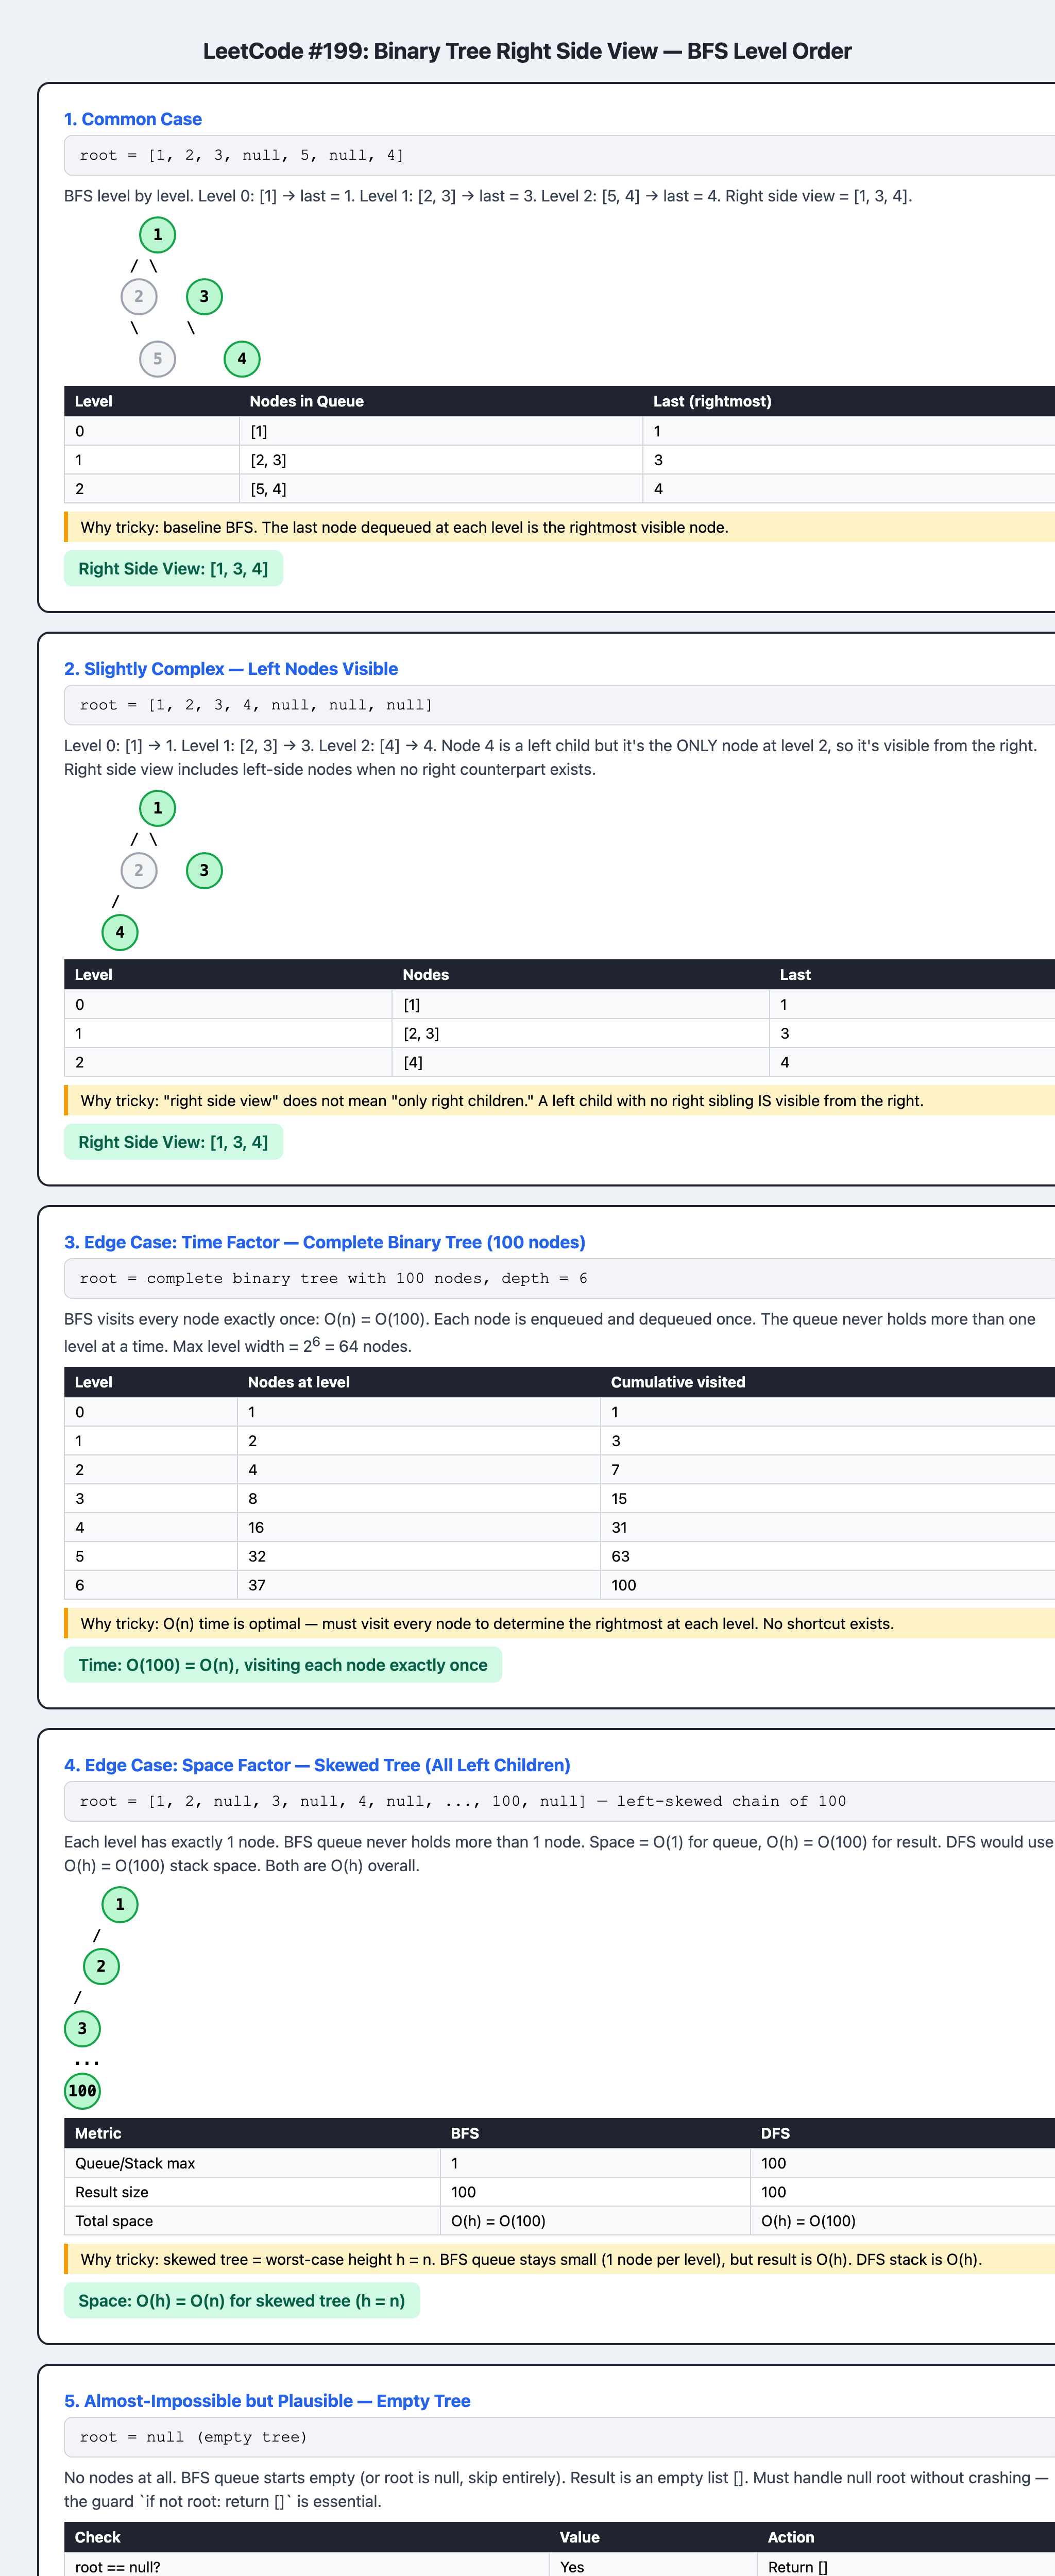